In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings("ignore")

In [8]:
df_nh = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
fund = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

print(df_nh.shape)
df_nh.head()

(64320, 4)


,date,amfi_code,nav,daily_return_pct
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-1.030568
2,2022-01-05,100016,521.7239,1.286515
3,2022-01-06,100016,515.7880,-1.137747
4,2022-01-07,100016,515.1639,-0.120999


In [23]:
df_nh['date'] = pd.to_datetime(df_nh['date'])

In [9]:
fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [10]:
df_nh = df_nh.merge(fund[['amfi_code', 'scheme_name']], on = 'amfi_code', how='left')

In [11]:
print("Total Records :", len(df_nh))
print("Unique Schemes :", df_nh['amfi_code'].nunique())

print("\nDate Range")
print(df_nh['date'].min())
print(df_nh['date'].max())

Total Records : 64320
Unique Schemes : 40

Date Range
2022-01-03
2026-05-29


In [12]:
df_nh.head()

,date,amfi_code,nav,daily_return_pct,scheme_name
0,2022-01-03,100016,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth
1,2022-01-04,100016,515.0971,-1.030568,HDFC Top 100 Fund - Regular Plan - Growth
2,2022-01-05,100016,521.7239,1.286515,HDFC Top 100 Fund - Regular Plan - Growth
3,2022-01-06,100016,515.7880,-1.137747,HDFC Top 100 Fund - Regular Plan - Growth
4,2022-01-07,100016,515.1639,-0.120999,HDFC Top 100 Fund - Regular Plan - Growth


## Plotly Daily NAV of All Schemes

In [14]:
fig = px.line(df_nh, x="date", y="nav", color="scheme_name", title="Daily NAV Trend of All Mutual Fund Schemes (2022-2026)", labels={"date":"Date", "nav":"NAV", "scheme_name":"Scheme"})

fig.update_traces(
    hovertemplate="<b>%{fullData.name}</b><br>Date: %{x|%d-%b-%Y}<br>NAV: %{y:.2f}<extra></extra>",
    hoverinfo='skip'
)

fig.update_layout(template = "plotly_white", height=700, hovermode="closest")

fig.show()

### Nav Trend

In [15]:
fig = px.line(df_nh, x="date", y="nav", color="scheme_name")

#COVID RECOVERY
fig.add_vrect(x0 = "2022-01-01", x1="2022-06-30", fillcolor="green", opacity=0.15, annotation_text="COVID Recovery", annotation_position="top left", line_width=0)

# 2023 Rally
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="blue",
    opacity=0.12,
    annotation_text="2023 Bull Run",
    annotation_position="top left",
    line_width=0
)

# 2024 Correction
fig.add_vrect(
    x0="2024-03-01",
    x1="2024-07-30",
    fillcolor="red",
    opacity=0.12,
    annotation_text="2024 Market Correction",
    annotation_position="top left",
    line_width=0
)

fig.update_layout(
    title="NAV Trend with Major Market Events",
    template="plotly_white",
    height=700
)

fig.show()

### Average NAV Across All Schemes

In [17]:
daily_avg = (
    df_nh.groupby('date')['nav']
    .mean()
    .reset_index()
)

fig = px.line(
    daily_avg,
    x='date',
    y='nav',
    title="Average Daily NAV Across All Schemes"
)

fig.add_vrect(
    x0="2022-01-01",
    x1="2022-06-30",
    fillcolor="green",
    opacity=0.15,
    line_width=0
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="blue",
    opacity=0.12,
    line_width=0
)

fig.add_vrect(
    x0="2024-03-01",
    x1="2024-07-30",
    fillcolor="red",
    opacity=0.12,
    line_width=0
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

### Monthly Average NAV

In [21]:
print(df_nh.dtypes)

date                 object
amfi_code             int64
nav                 float64
daily_return_pct    float64
scheme_name          object
dtype: object


In [27]:
monthly = (
    df_nh.groupby([
        pd.Grouper(key='date', freq='M'),
        'amfi_code','scheme_name'
    ])['nav']
    .mean()
    .reset_index()
)

fig = px.line(
    monthly,
    x='date',
    y='nav',
    color='scheme_name',
    title="Monthly Average NAV"
)

fig.update_layout(
    template="plotly_white",
    height=700
)

fig.show()

### Monthly Average (Overall)

In [28]:
overall = (
    df_nh
    .groupby(pd.Grouper(key='date',freq='M'))['nav']
    .mean()
    .reset_index()
)

fig = px.line(
    overall,
    x='date',
    y='nav',
    markers=True,
    title="Overall Monthly Average NAV"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="blue",
    opacity=0.12,
    line_width=0
)

fig.add_vrect(
    x0="2024-03-01",
    x1="2024-07-30",
    fillcolor="red",
    opacity=0.12,
    line_width=0
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

### Top 10 Highest NAV Schemes

In [30]:
latest = (
    df_nh.sort_values('date')
      .groupby('amfi_code')
      .tail(1)
)

latest = latest.sort_values('nav',ascending=False)

top10 = latest.head(10)

fig = px.bar(
    top10,
    x='scheme_name',
    y='nav',
    color='nav',
    title="Top 10 Schemes by Latest NAV"
)

fig.update_layout(
    template="plotly_white"
)

fig.show()

### NAV Growth Since 2022

In [36]:
first = (
    df_nh.groupby('amfi_code')
    .first()
    .reset_index()
)

last = (
    df_nh.groupby('amfi_code')
    .last()
    .reset_index()
)

growth = first[['amfi_code','nav']].rename(
    columns={'nav':'start_nav'}
)


growth['end_nav'] = last['nav']
growth['scheme_name'] = last['scheme_name']

growth['Growth %'] = (
    (growth['end_nav']-growth['start_nav'])
    /growth['start_nav']*100
)

growth = growth.sort_values(
    'Growth %',
    ascending=False
)

growth.head()

,amfi_code,start_nav,end_nav,scheme_name,Growth %
25,120505,135.8720,473.7640,ICICI Pru Midcap Fund - Regular - Growth,248.684056
21,119598,89.8738,309.2050,SBI Small Cap Fund - Regular Plan - Growth,244.043537
39,149324,81.6814,279.7511,DSP Small Cap Fund - Regular - Growth,242.490579
36,148569,28.8620,97.7435,Mirae Asset Tax Saver Fund - Regular - Growth,238.658097
34,148567,70.2514,230.2708,Mirae Asset Large Cap Fund - Regular - Growth,227.781083


### Growth Chart

In [37]:
fig = px.bar(
    growth,
    x='scheme_name',
    y='Growth %',
    color='Growth %',
    title="NAV Growth (2022-2026)"
)

fig.update_layout(
    template="plotly_white",
    xaxis_tickangle=-90,
    height=600
)

fig.show()

### Volatility (Standard Deviation)

In [47]:
volatility = (
    df_nh.groupby('amfi_code')['nav']
    .std()
    .sort_values(ascending=False)
)

volatility = volatility.reset_index()
volatility = volatility.merge(fund[['amfi_code', 'scheme_name']], on = 'amfi_code', how='left')

fig = px.bar(
    volatility,
    x='scheme_name',
    y='nav',
    color='nav',
    title="NAV Volatility (Standard Deviation)"
)

fig.update_layout(
    template="plotly_white",
    xaxis_tickangle=-90
)

fig.show()

# AUM Growth bar chart

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (14,7)

In [49]:
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv")

print(aum.shape)
aum.head()

(90, 5)


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [50]:
print(aum.dtypes)

date               object
fund_house         object
aum_lakh_crore    float64
aum_crore           int64
num_schemes         int64
dtype: object


In [51]:
aum['date'] = pd.to_datetime(aum['date'])

aum['year'] = aum['date'].dt.year

print(aum.dtypes)

date              datetime64[ns]
fund_house                object
aum_lakh_crore           float64
aum_crore                  int64
num_schemes                int64
year                       int32
dtype: object


In [53]:
print("Total Records : ", len(aum))
print("Fund Houses : ", aum['fund_house'].nunique())

print(aum['year'].nunique())

Total Records :  90
Fund Houses :  10
4


In [54]:
aum = aum[(aum['year'] >= 2022) & (aum['year'] <= 2025)]

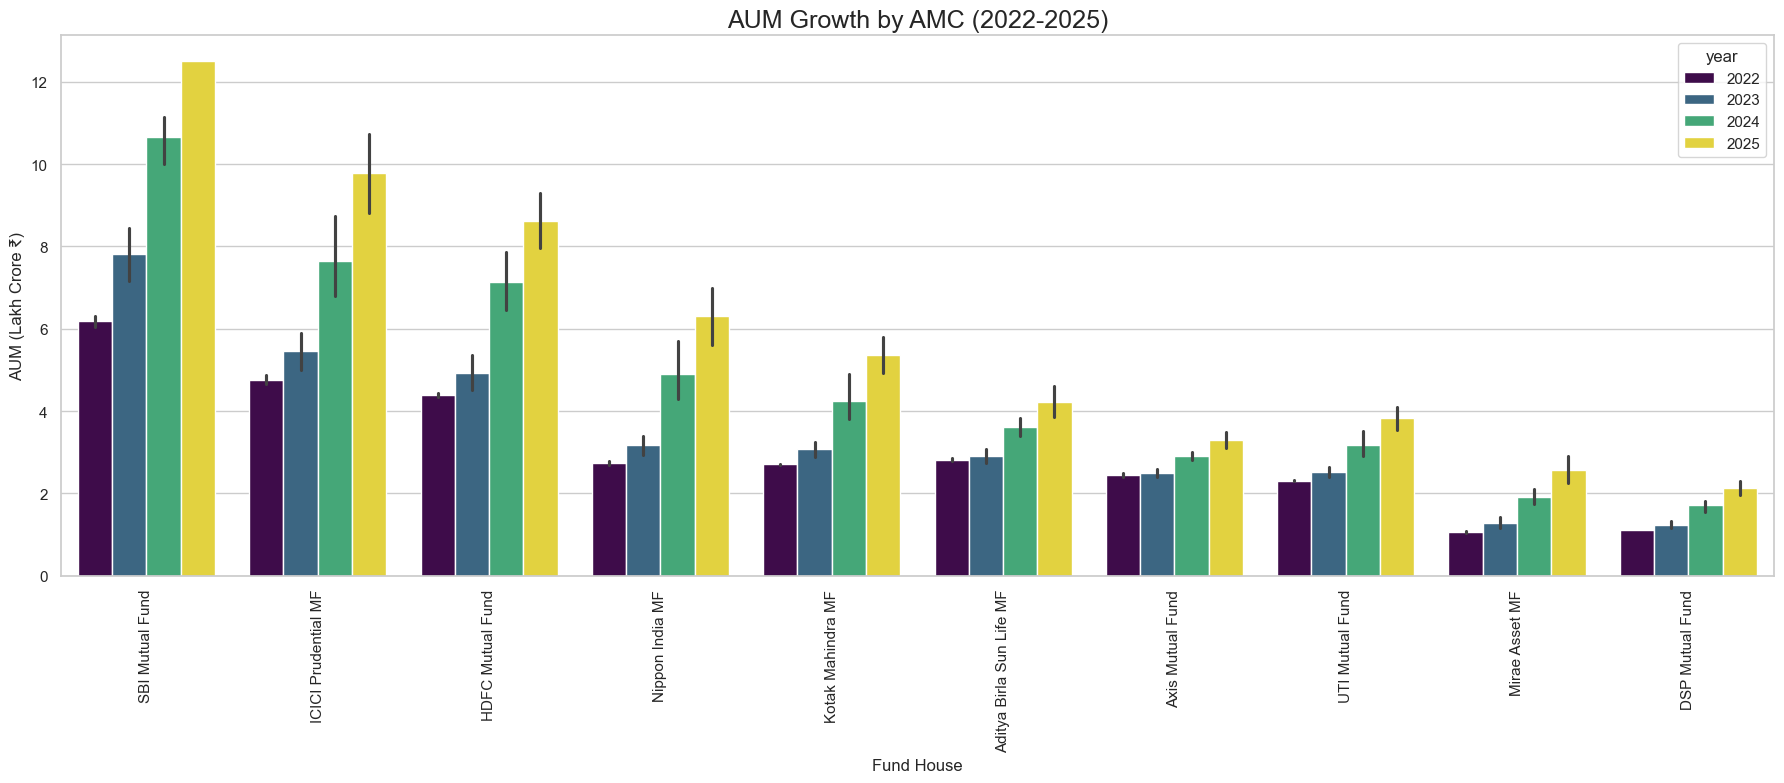

In [56]:
plt.figure(figsize=(18,8))

sns.barplot(
    data=aum,
    x='fund_house',
    y='aum_lakh_crore',
    hue='year',
    palette='viridis'
)

plt.xticks(rotation=90)

plt.title("AUM Growth by AMC (2022-2025)", fontsize=18)

plt.xlabel("Fund House")

plt.ylabel("AUM (Lakh Crore ₹)")

plt.tight_layout()

plt.show()

### Highlight SBI Mutual Fund

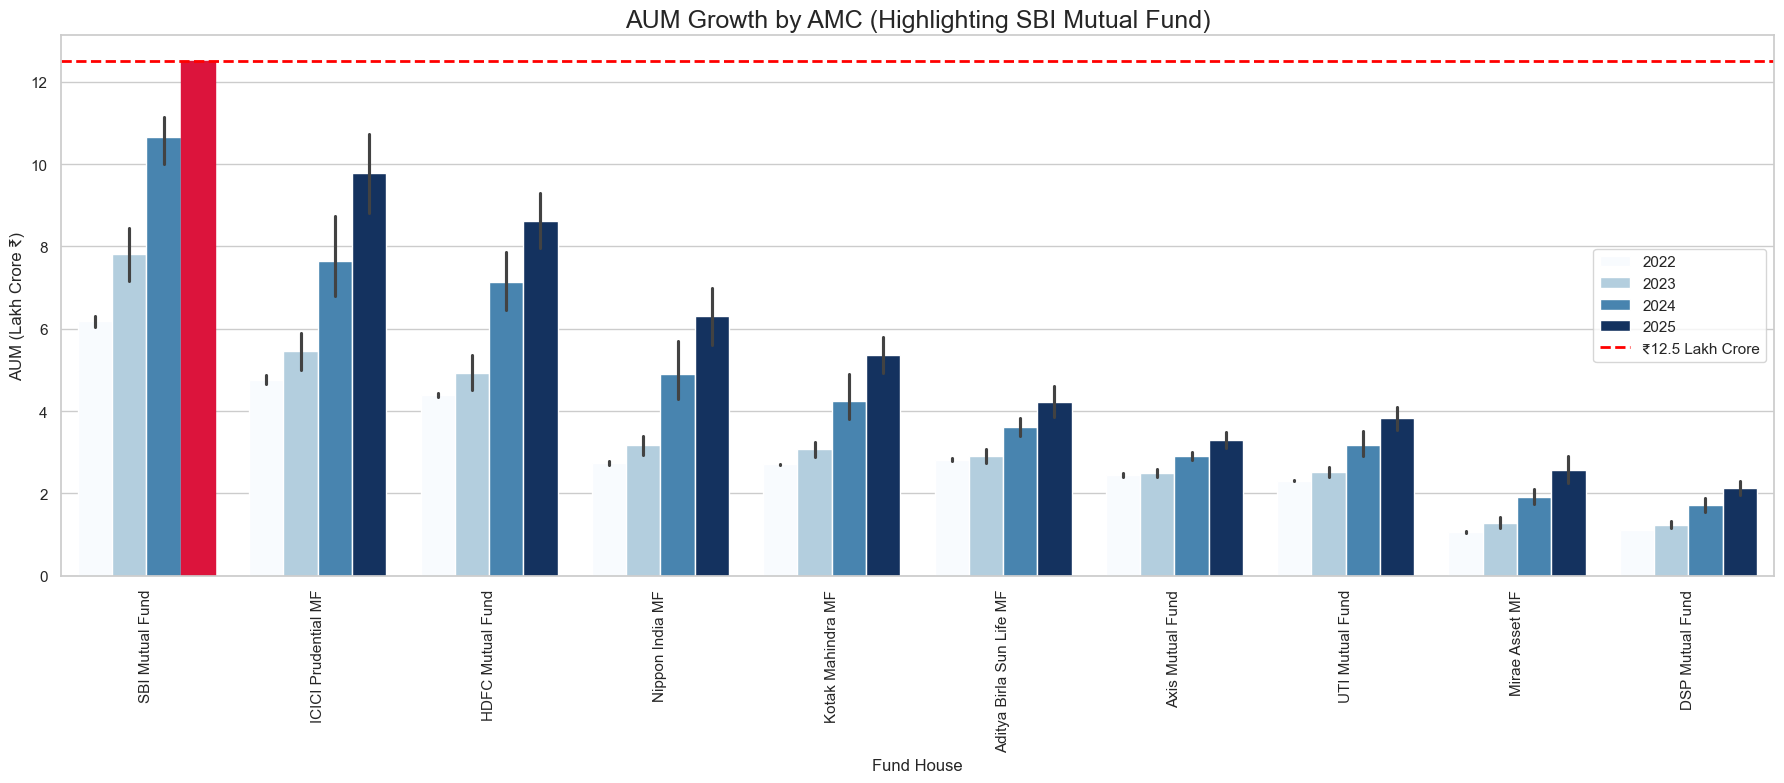

In [57]:
plt.figure(figsize=(18,8))

ax = sns.barplot(
    data=aum,
    x='fund_house',
    y='aum_lakh_crore',
    hue='year',
    palette='Blues'
)

plt.xticks(rotation=90)

plt.title("AUM Growth by AMC (Highlighting SBI Mutual Fund)", fontsize=18)

plt.xlabel("Fund House")

plt.ylabel("AUM (Lakh Crore ₹)")

# Highlight SBI
for container in ax.containers:
    for bar in container:
        if bar.get_height() > 12:
            bar.set_color("crimson")

plt.axhline(
    12.5,
    color='red',
    linestyle='--',
    linewidth=2,
    label='₹12.5 Lakh Crore'
)

plt.legend()

plt.tight_layout()

plt.show()

### Annotate SBI Value

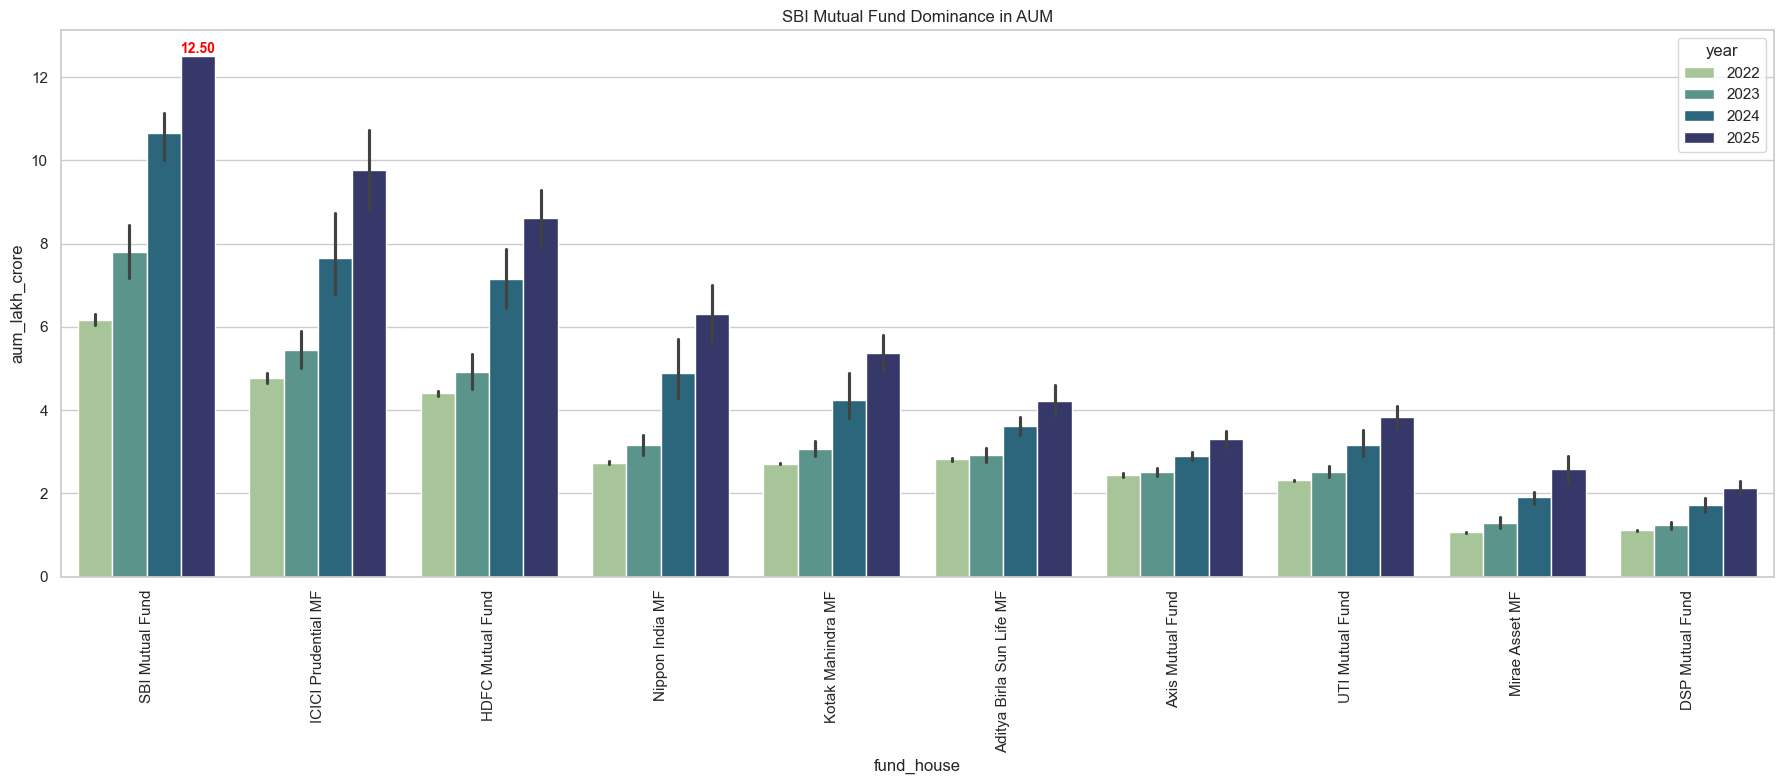

In [58]:
plt.figure(figsize=(18,8))

ax = sns.barplot(
    data=aum,
    x='fund_house',
    y='aum_lakh_crore',
    hue='year',
    palette='crest'
)

plt.xticks(rotation=90)

for p in ax.patches:

    if p.get_height() >= 12:

        ax.annotate(
            f"{p.get_height():.2f}",
            (
                p.get_x()+p.get_width()/2,
                p.get_height()
            ),
            ha='center',
            va='bottom',
            fontsize=10,
            color='red',
            fontweight='bold'
        )

plt.title("SBI Mutual Fund Dominance in AUM")

plt.tight_layout()

plt.show()

### Top 10 AMCs (Latest Year)

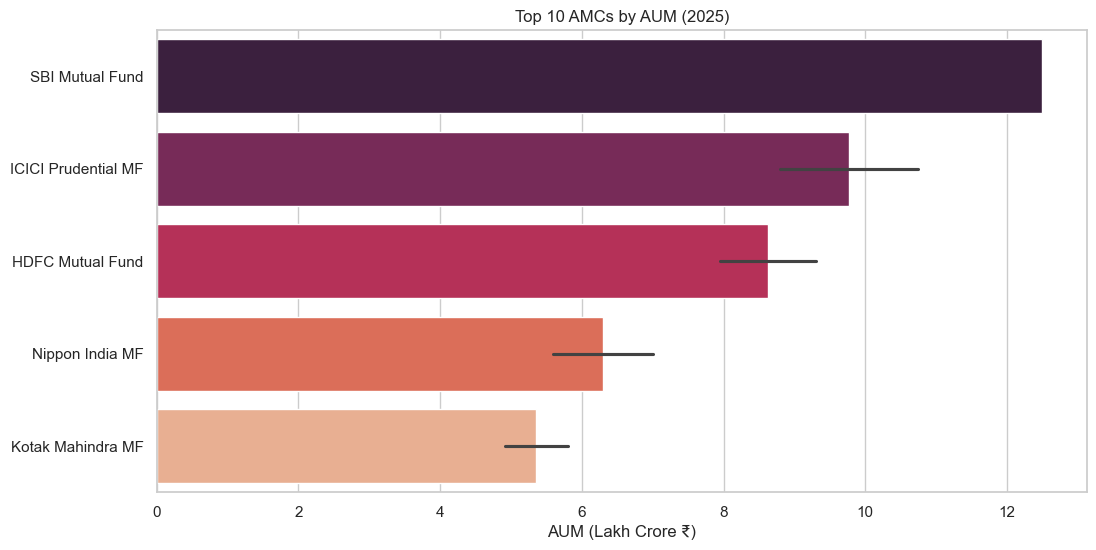

In [59]:
latest_year = aum['year'].max()

latest = (
    aum[aum['year']==latest_year]
    .sort_values('aum_lakh_crore',ascending=False)
)

top10 = latest.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='aum_lakh_crore',
    y='fund_house',
    palette='rocket'
)

plt.title(f"Top 10 AMCs by AUM ({latest_year})")

plt.xlabel("AUM (Lakh Crore ₹)")

plt.ylabel("")

plt.show()

# SIP Inflow Trend

In [61]:
df = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv")

print(df.shape)
df.head()

(48, 6)


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [62]:
df["month"] = pd.to_datetime(df["month"])

df = df.sort_values("month")

print(df.dtypes)

month                        datetime64[ns]
sip_inflow_crore                      int64
active_sip_accounts_crore           float64
new_sip_accounts_lakh               float64
sip_aum_lakh_crore                  float64
yoy_growth_pct                      float64
dtype: object


In [63]:
print("Total Months: ", len(df))

print("Start : ", df["month"].min())

print("End : ", df["month"].max())

df.describe()

Total Months:  48
Start :  2022-01-01 00:00:00
End :  2025-12-01 00:00:00


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
count,48,48.000000,48.000000,48.000000,48.000000,36.000000
mean,2023-12-16 11:00:00,19577.520833,7.189583,9.893750,8.632083,31.456944
min,2022-01-01 00:00:00,11438.000000,4.910000,7.500000,4.800000,15.800000
25%,2022-12-24 06:00:00,13658.500000,6.110000,8.775000,5.790000,20.245000
50%,2023-12-16 12:00:00,18224.000000,7.150000,9.200000,7.265000,28.295000
75%,2024-12-08 18:00:00,25944.250000,8.300000,9.562500,10.525000,40.807500
max,2025-12-01 00:00:00,31002.000000,9.350000,46.000000,15.900000,53.050000
std,NaN,6354.329621,1.271457,5.370745,3.613579,11.768190


### Monthly SIP inflow trend (MAIN CHART)

In [64]:
fig = px.line(
    df,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    labels={
        "month":"Month",
        "sip_inflow_crore":"SIP Inflow (₹ Crore)"
    }
)

fig.update_traces(
    line=dict(width=3),
    hovertemplate=
    "<b>%{x|%b %Y}</b><br>"
    "SIP Inflow: ₹%{y:,.0f} Cr"
    "<extra></extra>"
)

fig.update_layout(
    template="plotly_white",
    hovermode="closest",
    height=600
)

fig.show()

### Highlight ₹31,002 Crore Milestone (Dec 2025)

In [66]:
peak = df.loc[df["sip_inflow_crore"].idxmax()]

fig = px.line(
    df,
    x="month",
    y="sip_inflow_crore",
    markers=True
)

fig.add_trace(
    go.Scatter(
        x=[peak["month"]],
        y=[peak["sip_inflow_crore"]],
        mode="markers",
        marker=dict(
            color="red",
            size=12
        ),
        showlegend=False
    )
)

fig.add_annotation(
    x=peak["month"],
    y=peak["sip_inflow_crore"],
    text="₹31,002 Cr<br>All-Time High<br>Dec 2025",
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow",
    bordercolor="black"
)

fig.update_layout(
    title="Monthly SIP Inflow with Dec 2025 Milestone",
    template="plotly_white",
    hovermode="closest",
    height=600
)

fig.show()

### Active SIP Accounts Trend

In [67]:
fig = px.line(
    df,
    x="month",
    y="active_sip_accounts_crore",
    markers=True,
    title="Active SIP Accounts",
    labels={
        "active_sip_accounts_crore":"Accounts (Crore)"
    }
)

fig.update_layout(
    template="plotly_white",
    height=550
)

fig.show()

# Category Inflow Heatmap

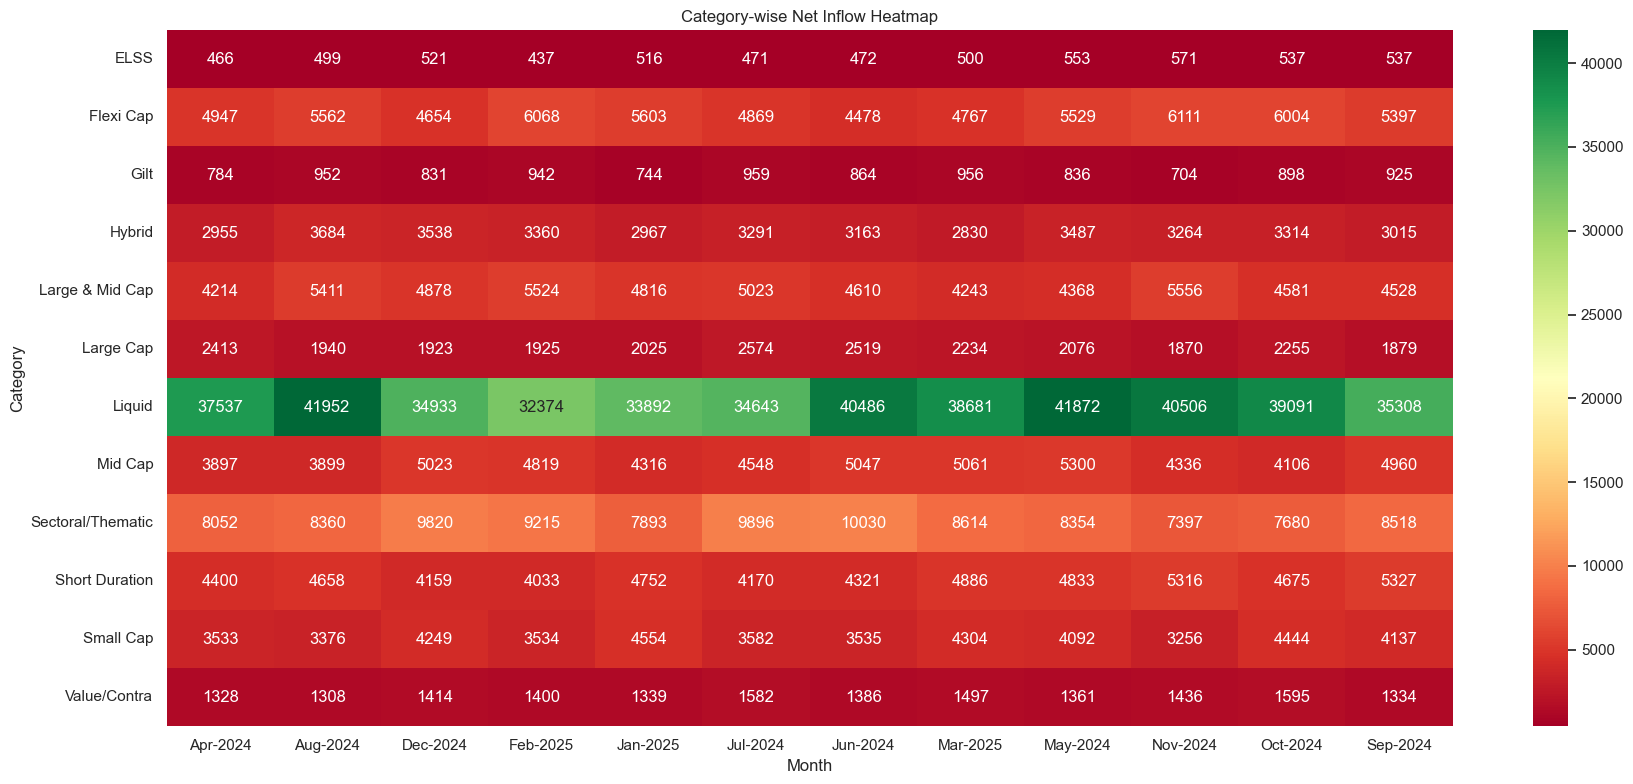

In [69]:
df = pd.read_csv("../data/processed/05_category_inflows_cleaned.csv")

df["month"] = pd.to_datetime(df["month"])

pivot = df.pivot_table(
    index="category",
    columns=df["month"].dt.strftime("%b-%Y"),
    values="net_inflow_crore"
)

plt.figure(figsize=(18,8))

sns.heatmap(
    pivot,
    cmap="RdYlGn",
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Net Inflow Heatmap")

plt.xlabel("Month")

plt.ylabel("Category")

plt.tight_layout()

plt.show()

# Investor Demographics

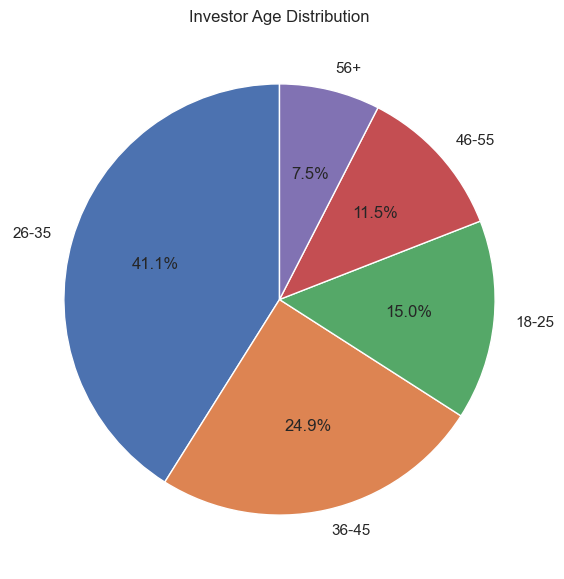

In [70]:
# Age distribution

df = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

age = df["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age,
    labels=age.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Distribution")

plt.show()

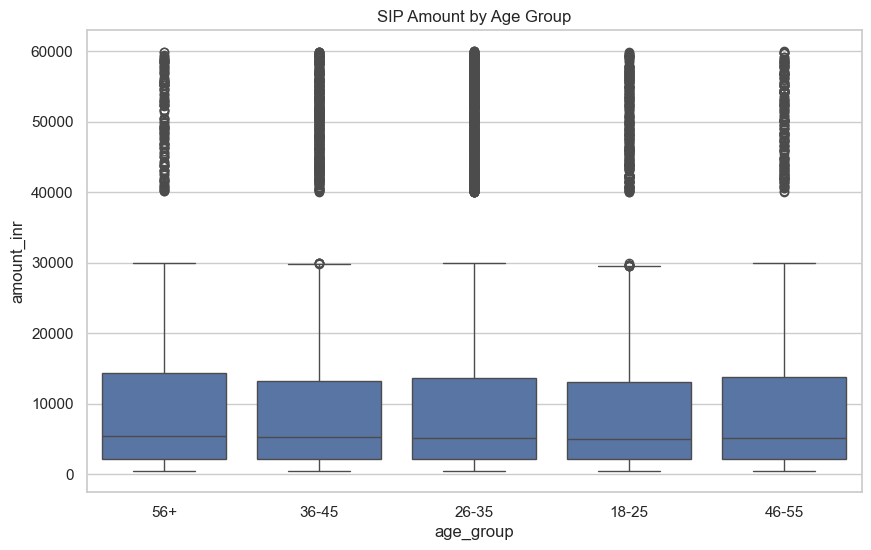

In [71]:
# SIP Amount Boxplot

sip = df[df["transaction_type"]=="SIP"]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")

plt.show()

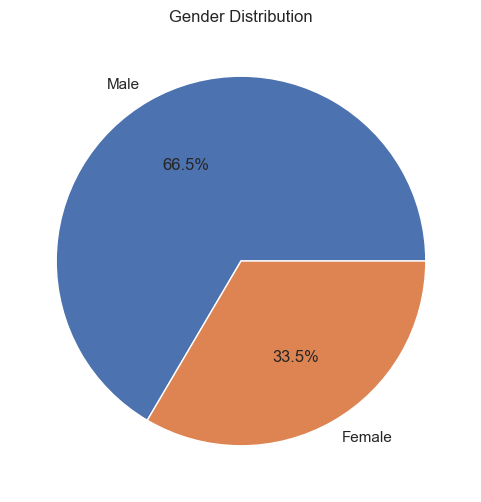

In [72]:
# Gender split

gender = df["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

# Geographic Distribution

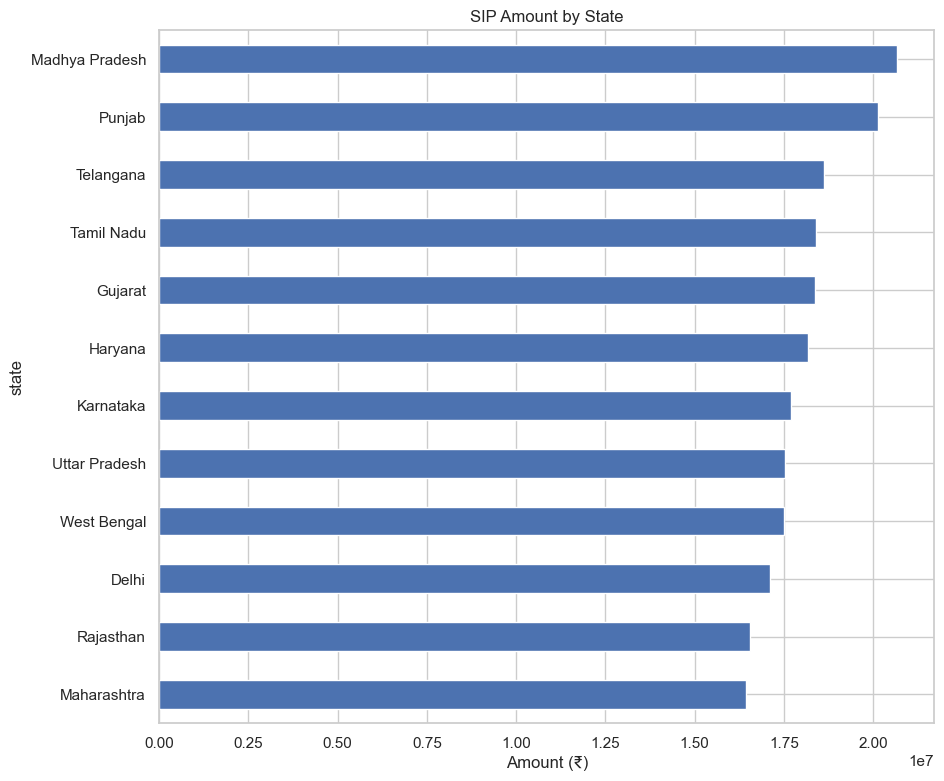

In [73]:
#Sip amount by state 

state = (
    sip.groupby("state")["amount_inr"]
       .sum()
       .sort_values()
)

plt.figure(figsize=(10,9))

state.plot.barh()

plt.title("SIP Amount by State")

plt.xlabel("Amount (₹)")

plt.show()

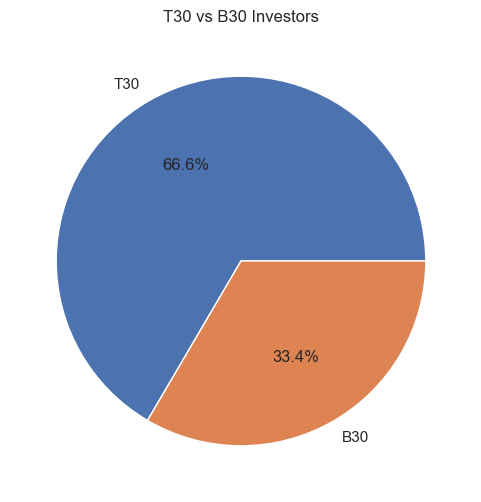

In [74]:
# T30 vs B30
tier = sip["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investors")

plt.show()

# Folio Count Growth

In [75]:
df = pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv")

df["month"] = pd.to_datetime(df["month"])

In [76]:
import plotly.express as px

fig = px.line(
    df,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Industry Folio Count Growth"
)

fig.add_annotation(
    x=df.iloc[0]["month"],
    y=df.iloc[0]["total_folios_crore"],
    text="13.26 Cr",
    showarrow=True
)

fig.add_annotation(
    x=df.iloc[-1]["month"],
    y=df.iloc[-1]["total_folios_crore"],
    text="26.12 Cr",
    showarrow=True
)

fig.show()

# NAV Return Correlation Matrix

In [79]:
codes = fund["amfi_code"].head(10)

df_nh = df_nh[df_nh["amfi_code"].isin(codes)]

In [84]:
pivot = df_nh.pivot(
    index = "date",
    columns="scheme_name",
    values="nav"
)

In [85]:
returns = pivot.pct_change().dropna()

In [87]:
corr = returns.corr()

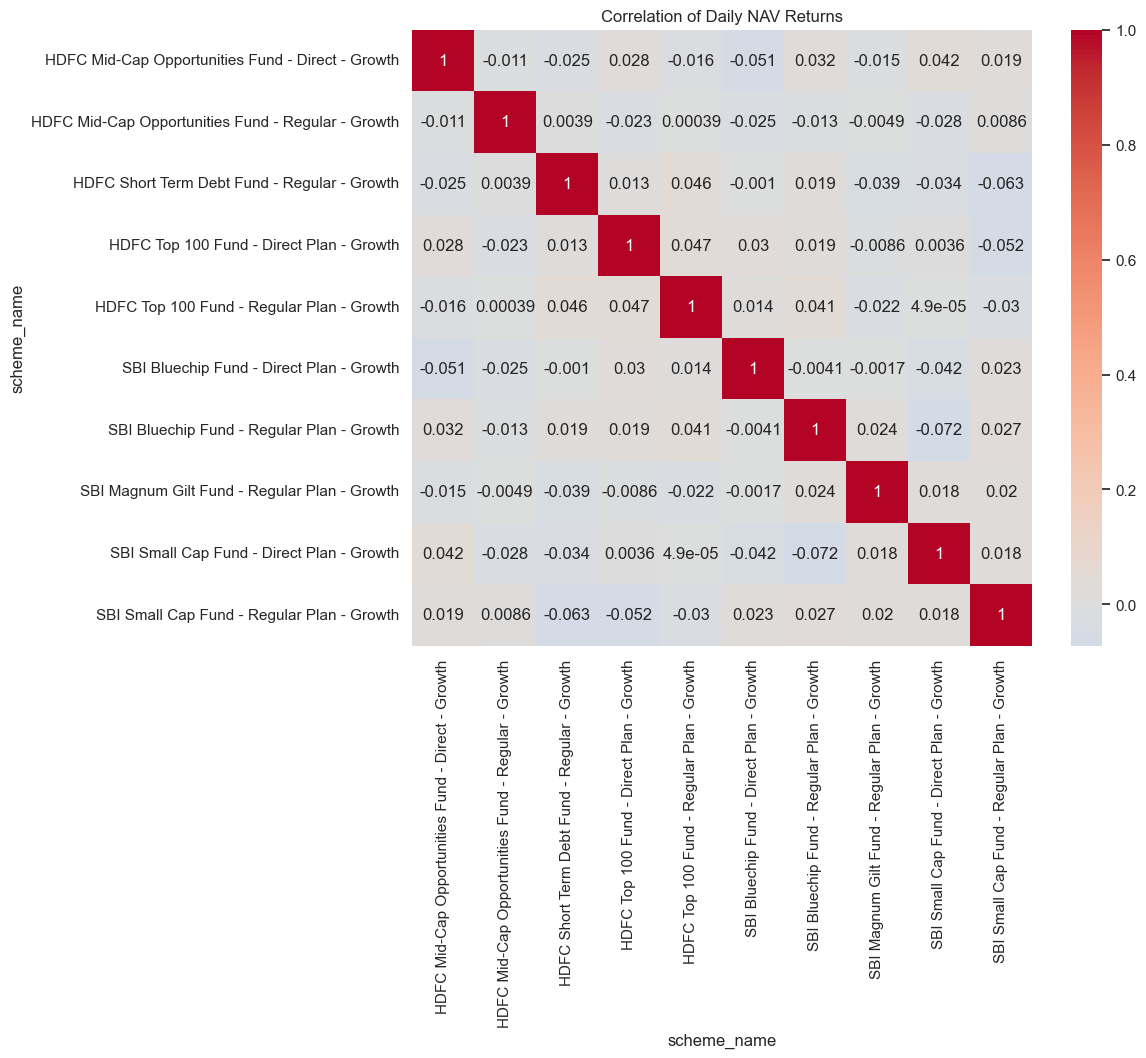

In [88]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation of Daily NAV Returns")

plt.show()

# Sector Allocation Donut

In [90]:
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

In [92]:
portfolio  = portfolio.merge(
    fund[["amfi_code","category","scheme_name"]],
    on="amfi_code"
)

In [93]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,category,scheme_name
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,Equity,SBI Bluechip Fund - Regular Plan - Growth
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,Equity,SBI Bluechip Fund - Regular Plan - Growth
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,Equity,SBI Bluechip Fund - Regular Plan - Growth
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,Equity,SBI Bluechip Fund - Regular Plan - Growth
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,Equity,SBI Bluechip Fund - Regular Plan - Growth


In [94]:
portfolio = portfolio[
    portfolio["category"].str.contains("Equity",case=False)
]

In [95]:
sector = (
    portfolio.groupby("sector")["weight_pct"].sum()
)

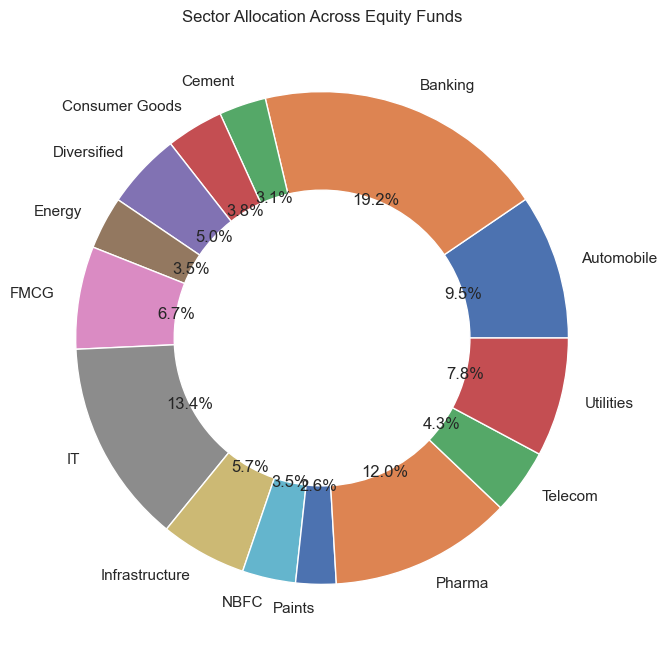

In [96]:
plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

### Markdown

Banking and IT Sector are the most largest aggregate allocation across equity portfolios with percentage share around 32.2% combined, followed by Pharma sector

## Insight 1
Liquid Categroy Has the most inflow in each quarter, even 5x then the second higher which is Sectoral/Thematic (Category Inflow Heatmap).

## Insight 2
The 26–35 age group contributed the highest number of SIP transactions but we can see there are investors age 18-25 more than the investors of age 46-55 showing young people are growing interest investing in Mutual Funds (Age Distribution).

## Insight 3
Median SIP amount increases with investor age but only there is age 46-55 which show a decrease in median even less than the 18-25 age (SIP Boxplot).

## Insight 4
Male investors account for a larger share of transactions than female investors about 2x times more (Gender Pie Chart).

## Insight 5
Most Sip is done by people of MP and Punjab. Also Major investors around 66.6% are from T30 meaning Top 30 Tier 1 cities. (City Tier Pie Chart).

## Insight 6
Madhya Pradesh and Punjab generate the highest cumulative SIP investments (State Bar Chart).

## Insight 7
Industry folio count nearly doubled from 13.26 Cr to 26.12 Cr during the study period (Folio Growth).

## Insight 8
Daily returns of large-cap equity funds show strong positive correlation like 
- SBI small cap Fund - Regular Plan - Growth is most positively correlated fund with other SBI, telling it grows when any of the SBI Fund grows 
- Most positively correlated funds are HDFC Top 100 Regular and Direct Growth Plans (Correlation Heatmap).

## Insight 9
Financials/Banking dominate aggregate equity portfolio allocation followed by IT and Pharma (Sector Donut Chart).

## Insight 10

### Covid Recovery (2022) 

- 2nd Highest time HDFC regular plan show decline whereas HDFC direct plan shows increase in nav of the fund (NAV Trend)

### 2023 Bull Run

- HDFC Direct Plan shows bull run in the year 2023 by increasing by 200 points (NAV Trend)

## Insight 11

SBI Mutual Fund(2x) > ICICI Prudential MF(2x) > HDFC MF(2x) > Nippon(3x) > Kotak Mahindra MF(2x) are the mutual funds in decreasing order from left to right also showing how much they AUM under them increased from 2022 to 2025, SBI Being the highest Fund Manager (SBI Mutual Fund Highlight)